# Preparation

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/test.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/sample_submission.zip


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Styling defaults

In [3]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# Data overview

In [4]:
df = pd.read_csv('/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip')

print('Shape: ', df.shape)
df.head()

Shape:  (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [5]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "nulls": df.isnull().sum(),
    "nunique": df.nunique()
})

print(info.to_string())

                      dtype  nulls  nunique
id                   object      0  1458644
vendor_id             int64      0        2
pickup_datetime      object      0  1380222
dropoff_datetime     object      0  1380377
passenger_count       int64      0       10
pickup_longitude    float64      0    23047
pickup_latitude     float64      0    45245
dropoff_longitude   float64      0    33821
dropoff_latitude    float64      0    62519
store_and_fwd_flag   object      0        2
trip_duration         int64      0     7417


In [6]:
df['id'].duplicated().sum()

np.int64(0)

In [7]:
df.drop(columns=['id'], inplace=True)

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df.dtypes

vendor_id                      int64
pickup_datetime       datetime64[ns]
dropoff_datetime              object
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

# Data cleaning

In [8]:
# Passengers outside New York
display(df[df['pickup_latitude'] < 40.50].head(2))

# Inconsistent datetime outputs
display(df[df['trip_duration'] == 1].head(2))

# Passengers that are not hiring a cab
display(df[df['trip_duration'] == 0].head(2))

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
47554,2,2016-01-09 14:58:08,2016-01-09 15:13:20,1,-74.079620,40.449749,-74.062263,40.444698,N,912
73032,2,2016-01-16 10:03:02,2016-01-16 10:12:44,1,-74.069733,40.433842,-74.082153,40.441662,N,582


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
35196,1,2016-04-17 11:44:49,2016-04-17 11:44:50,1,-73.940384,40.786423,-73.940300,40.786373,N,1
207497,1,2016-05-17 09:03:38,2016-05-17 09:03:39,1,-73.819893,40.740822,-73.819885,40.740822,N,1


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration


In [9]:
def clean_data(X: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans raw taxi trip data before feature engineering.

    This function removes unrealistic or corrupted rows based on:
      1. Trip duration bounds
      2. Geographic bounding box for NYC
      3. Valid passenger count

    It ensures the model trains only on plausible trips,
    reducing noise and improving stability.
    """

    # Define acceptable trip duration range in seconds
    # Very short trips are likely sensor glitches
    # Very long trips are usually data errors
    min_duration = 10
    max_duration = 10_800

    # Approximate geographic bounding box for its state
    # Used to remove outliers far outside the service area
    lat_min, lat_max =  40.50,  40.93
    lon_min, lon_max = -74.25, -73.65

    # Keep trips within the valid duration range
    mask_duration = X['trip_duration'].between(min_duration, max_duration)

    # Keep pickup locations inside the city's bounding box
    mask_pickup = (
        X['pickup_latitude'].between(lat_min, lat_max) & 
        X['pickup_longitude'].between(lon_min, lon_max)
    )

    # Keep drop-off locations inside the city's bounding box
    mask_dropoff = (
        X['dropoff_latitude'].between(lat_min, lat_max) & 
        X['dropoff_longitude'].between(lon_min, lon_max)
    )

    # Remove trips with zero or negative passengers
    mask_passenger = X['passenger_count'] > 0

    # Apply all filters together
    # Only rows satisfying all conditions are kept
    X = X[mask_duration & mask_pickup & mask_dropoff & mask_passenger].copy()

    # Reset index after row removal to keep dataset clean
    X.reset_index(drop=True, inplace=True)

    return X

rows_before = len(df)
print(f"Rows before cleaning: {rows_before:,}")

df = clean_data(df)
print(f"Rows after cleaning: {len(df):,}")
print(f"Removed: {rows_before - len(df):,} rows")

Rows before cleaning: 1,458,644
Rows after cleaning: 1,453,522
Removed: 5,122 rows


# Feature engineering

In [10]:
earth_radius_km = 6_371.0

def calculate_distance(lon1, lat1, lon2, lat2):
    """
    Haversine formula — great-circle distance between two points on Earth.
    Returns distance in kilometers.
    """
    # Convert decimal degrees to radians
    phi1, phi2       = np.radians(lat1), np.radians(lat2)
    d_phi            = np.radians(lat2 - lat1)
    d_lambda         = np.radians(lon2 - lon1)

    # Core formula
    a = (np.sin(d_phi   / 2) ** 2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(d_lambda / 2) ** 2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Kilometers
    return earth_radius_km * c

def calculate_bearing(lon1, lat1, lon2, lat2):
    """
    Forward azimuth (bearing) from point 1 → point 2.
    Returns angle in degrees (−180 to +180).
    Useful as a proxy for traffic corridor direction.
    """
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    d_lon = lon2 - lon1
    y     = np.sin(d_lon) * np.cos(lat2)
    x     = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(d_lon)
    return np.degrees(np.arctan2(y, x))

# Apply spatial features
df['distance_km'] = calculate_distance(
    df['pickup_longitude'],  df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

df['bearing'] = calculate_bearing(
    df['pickup_longitude'],  df['pickup_latitude'],
    df['dropoff_longitude'], df['dropoff_latitude']
)

In [11]:
# Temporal features
dt = df['pickup_datetime'].dt

df['hour']       = dt.hour
df['dayofweek']  = dt.dayofweek
df['month']      = dt.month
df['day_of_week_name'] = dt.day_name()
df['is_weekend'] = (dt.dayofweek >= 5).astype(int)

In [12]:
# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']  = np.sin(2 * np.pi * df['dayofweek'] /  7)
df['day_cos']  = np.cos(2 * np.pi * df['dayofweek'] /  7)

In [13]:
# Average speed (in kilometers)
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

In [14]:
# Remove the datetime column
df.drop(columns=['pickup_datetime'], inplace=True)

print("All features engineered successfully.")
print(f"Final shape: {df.shape}")
df.head()

All features engineered successfully.
Final shape: (1453522, 21)


,vendor_id,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,distance_km,...,hour,dayofweek,month,day_of_week_name,is_weekend,hour_sin,hour_cos,day_sin,day_cos,speed_kmh
0,2,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,1.498521,...,17,0,3,Monday,0,-0.965926,-0.258819,0.000000,1.000000,11.856428
1,1,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,1.805507,...,0,6,6,Sunday,1,0.000000,1.000000,-0.781831,0.623490,9.803659
2,2,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,6.385098,...,11,1,1,Tuesday,0,0.258819,-0.965926,0.781831,0.623490,10.822201
3,2,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1.485498,...,19,2,4,Wednesday,0,-0.965926,0.258819,0.974928,-0.222521,12.465721
4,2,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1.188588,...,13,5,3,Saturday,1,-0.258819,-0.965926,-0.974928,-0.222521,9.836594


# Exploratory Data Analysis

In [15]:
# Basic statistics
df.describe().T.style.background_gradient(
    cmap='BuPu',
    subset=['mean', '50%', 'std']
)

,count,mean,std,min,25%,50%,75%,max
vendor_id,1453522.000000,1.534586,0.498803,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,1453522.000000,1.664691,1.314177,1.000000,1.000000,1.000000,2.000000,9.000000
pickup_longitude,1453522.000000,-73.973552,0.037915,-74.233780,-73.991867,-73.981750,-73.967392,-73.652458
pickup_latitude,1453522.000000,40.750975,0.027941,40.506294,40.737389,40.754120,40.768360,40.927170
dropoff_longitude,1453522.000000,-73.973514,0.035005,-74.248909,-73.991325,-73.979767,-73.963081,-73.650009
dropoff_latitude,1453522.000000,40.751786,0.031959,40.508598,40.735920,40.754532,40.769798,40.929810
trip_duration,1453522.000000,836.986337,656.172686,10.000000,398.000000,662.000000,1073.000000,10731.000000
distance_km,1453522.000000,3.424947,3.875685,0.000000,1.234625,2.095548,3.874101,45.109645
bearing,1453522.000000,-15.720452,104.530253,-179.992701,-125.427527,8.253495,53.394026,180.000000
hour,1453522.000000,13.608225,6.398056,0.000000,9.000000,14.000000,19.000000,23.000000


Median trip: 11.0 minutes
Mean trip: 13.9 minutes
Skewness: 2.30


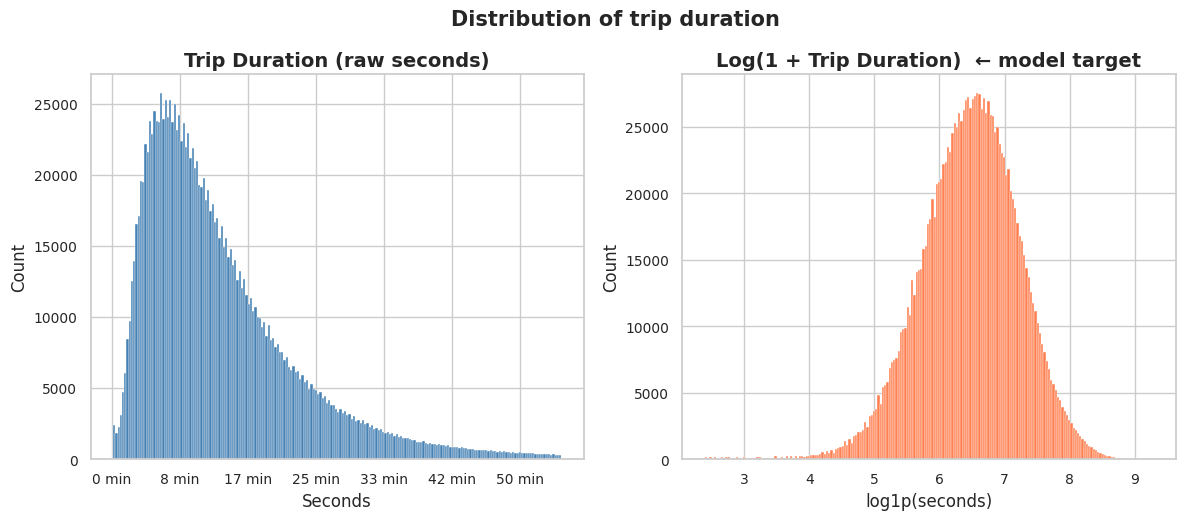

In [16]:
# Trip duration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw duration (trimmed at 99th percentile for readability)
cap = df['trip_duration'].quantile(0.99)
axes[0].hist(df.loc[df['trip_duration'] <= cap, 'trip_duration'],
             bins=200, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title("Trip Duration (raw seconds)")
axes[0].set_xlabel("Seconds")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f} min")) # X in mins. instead of secs.

# Log-transformed duration
axes[1].hist(np.log1p(df['trip_duration']),
             bins=200, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title("Log(1 + Trip Duration)  ← model target")
axes[1].set_xlabel("log1p(seconds)")

for ax in axes:
    ax.set_ylabel("Count")

plt.suptitle(
    "Distribution of trip duration",
    fontsize=15,
    fontweight='bold',
    y=1.01
)

print(f"Median trip: {df['trip_duration'].median()/60:.1f} minutes")
print(f"Mean trip: {df['trip_duration'].mean()/60:.1f} minutes")
print(f"Skewness: {df['trip_duration'].skew():.2f}")

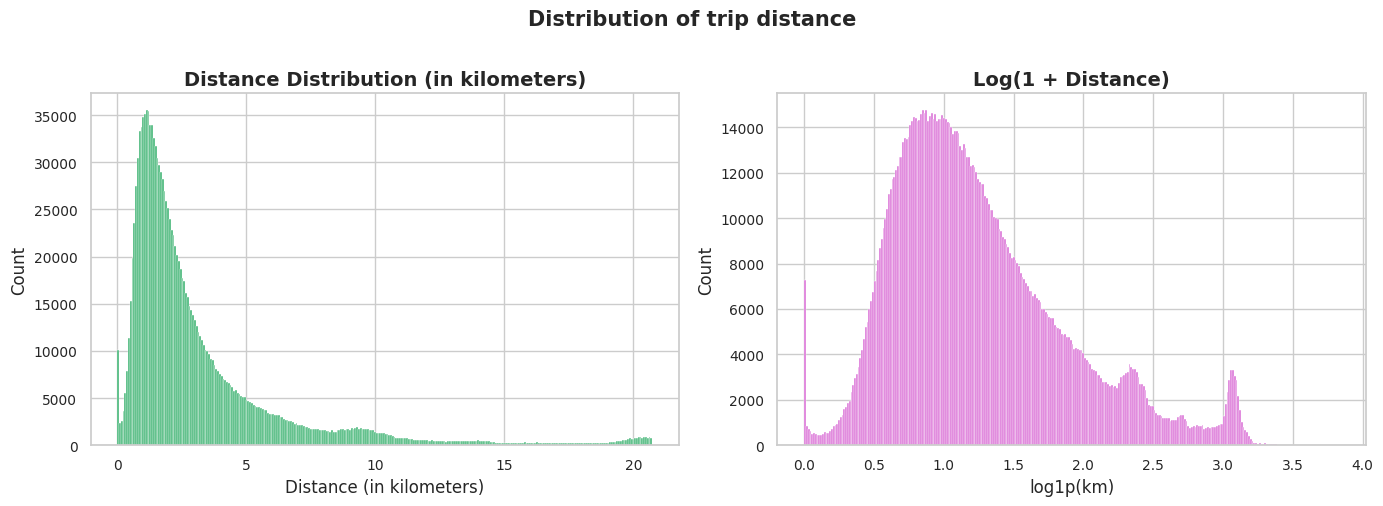

Median distance: 2.10 km
Mean distance: 3.42 km


In [17]:
# Distance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap_dist = df['distance_km'].quantile(0.99)

axes[0].hist(df.loc[df['distance_km'] <= cap_dist, 'distance_km'],
             bins=300, color='mediumseagreen', edgecolor='white', linewidth=0.3)
axes[0].set_title("Distance Distribution (in kilometers)")
axes[0].set_xlabel("Distance (in kilometers)")

axes[1].hist(np.log1p(df['distance_km']),
             bins=300, color='orchid', edgecolor='white', linewidth=0.3)
axes[1].set_title("Log(1 + Distance)")
axes[1].set_xlabel("log1p(km)")

for ax in axes:
    ax.set_ylabel("Count")

plt.suptitle("Distribution of trip distance", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Median distance: {df['distance_km'].median():.2f} km")
print(f"Mean distance: {df['distance_km'].mean():.2f} km")

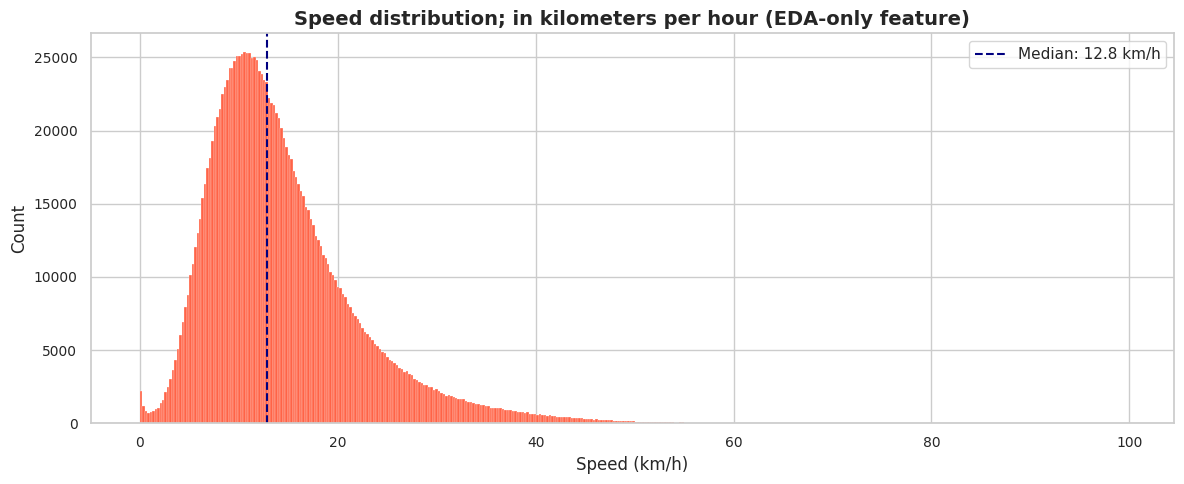

Trips with speed below 1 km/h: 10,086 ← GPS inconsistency
Trips with speed above 80 km/h: 122 ← suspiciously fast


In [18]:
# Speed distribution
speed_eda = df['speed_kmh'][(df['speed_kmh'] > 0) & (df['speed_kmh'] <= 100)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(speed_eda, bins=400, color='tomato', edgecolor='white', linewidth=0.2)
ax.set_title("Speed distribution; in kilometers per hour (EDA-only feature)")
ax.set_xlabel("Speed (km/h)")
ax.set_ylabel("Count")
ax.axvline(speed_eda.median(), color='navy', linestyle='--', linewidth=1.5,
           label=f"Median: {speed_eda.median():.1f} km/h")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trips with speed below 1 km/h: {(df['speed_kmh'] < 1).sum():,} ← GPS inconsistency")
print(f"Trips with speed above 80 km/h: {(df['speed_kmh'] > 80).sum():,} ← suspiciously fast")

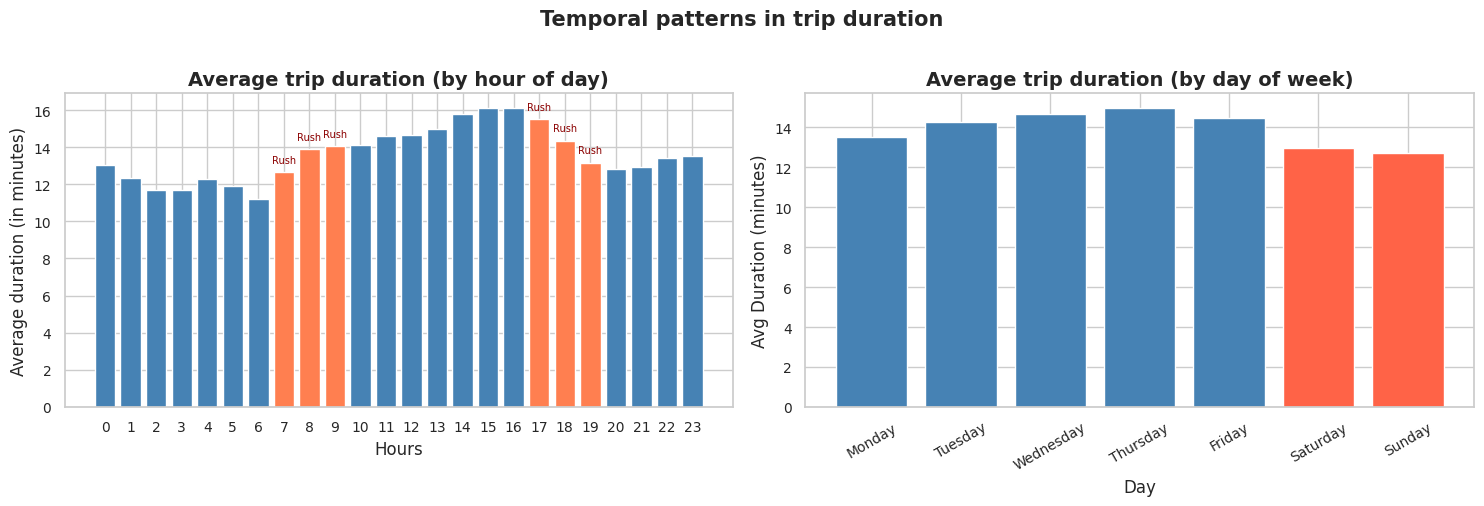

In [20]:
# Hourly and weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trips per hour
hourly = df.groupby('hour')['trip_duration'].agg(['mean','count'])

color = ['coral' if h in [7,8,9,17,18,19] else 'steelblue' for h in hourly.index]
axes[0].bar(hourly.index, hourly['mean'] / 60, color=color, edgecolor='white')
axes[0].set_title("Average trip duration (by hour of day)")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Average duration (in minutes)")
axes[0].set_xticks(range(0, 24))

# Annotate rush hours
for h in [7, 8, 9, 17, 18, 19]:
    axes[0].annotate("Rush", xy=(h, hourly.loc[h,'mean']/60),
                     xytext=(h, hourly.loc[h,'mean']/60 + 0.5),
                     fontsize=7, ha='center', color='darkred')

# Trips of day per week
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily       = df.groupby('day_of_week_name')['trip_duration'].mean().reindex(day_order) / 60
weekend_col = ['tomato' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order] # weekend

axes[1].bar(daily.index, daily.values, color=weekend_col, edgecolor='white')
axes[1].set_title("Average trip duration (by day of week)")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Duration (minutes)")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Temporal patterns in trip duration", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

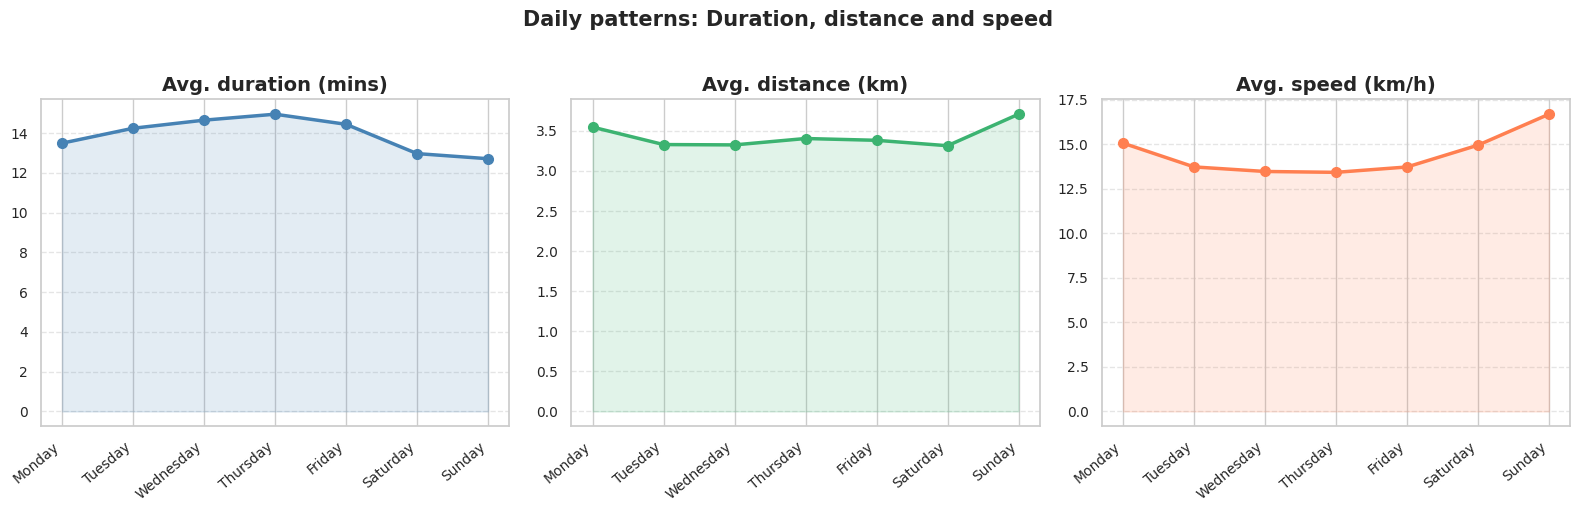

In [22]:
# Duration, distance, and speed
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
agg = df.groupby('day_of_week_name').agg(
    avg_duration = ('trip_duration', 'mean'),
    avg_distance = ('distance_km',   'mean'),
    avg_speed    = ('speed_kmh',     'mean'),
).reindex(day_order)
agg['avg_duration'] /= 60   # convert to mins.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics  = ['avg_duration', 'avg_distance', 'avg_speed']
titles   = ['Avg. duration (mins)', 'Avg. distance (km)', 'Avg. speed (km/h)']
colors   = ['steelblue', 'mediumseagreen', 'coral']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(agg.index, agg[metric], marker='o', linewidth=2.5,
            markersize=7, color=color)
    ax.fill_between(range(7), agg[metric].values, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_order, rotation=40, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Daily patterns: Duration, distance and speed", fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

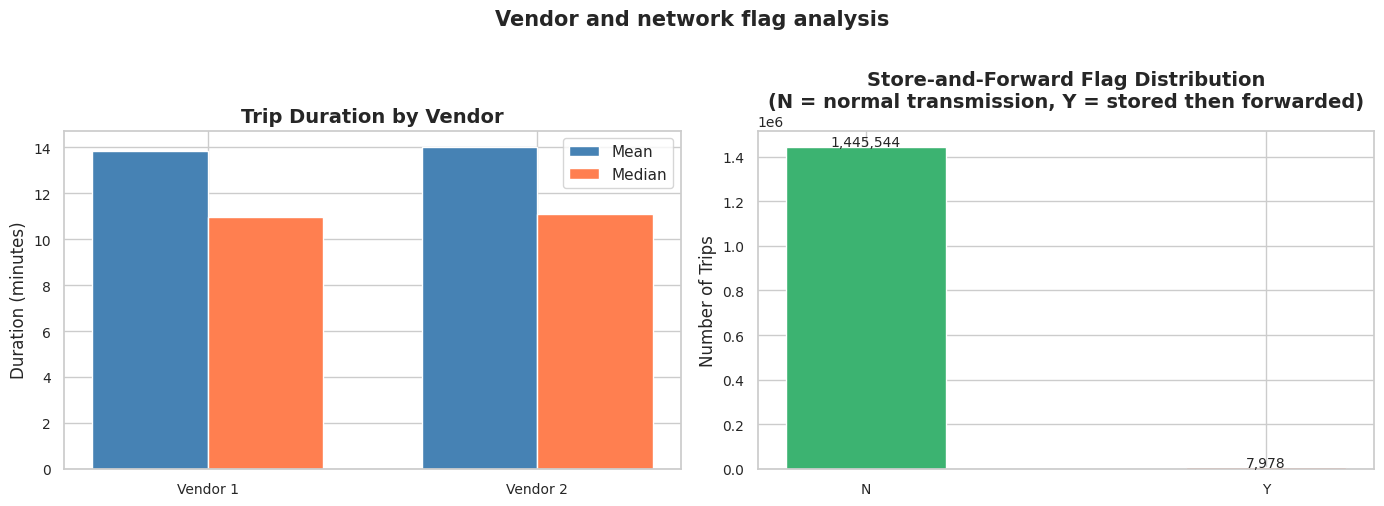

In [23]:
# Vendor, store, and forward-flag
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vendor and duration intervals
vendor_stats = df.groupby('vendor_id')['trip_duration'].agg(['mean','median'])
vendor_stats /= 60   # convert to mins.

x = range(len(vendor_stats))
w = 0.35
axes[0].bar([i - w/2 for i in x], vendor_stats['mean'],   width=w, label='Mean',   color='steelblue')
axes[0].bar([i + w/2 for i in x], vendor_stats['median'], width=w, label='Median', color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([f"Vendor {v}" for v in vendor_stats.index])
axes[0].set_ylabel("Duration (minutes)")
axes[0].set_title("Trip Duration by Vendor")
axes[0].legend()

# Store and forward flag
flag_counts = df['store_and_fwd_flag'].value_counts()
axes[1].bar(flag_counts.index, flag_counts.values,
            color=['mediumseagreen','tomato'], edgecolor='white', width=0.4)
axes[1].set_title("Store-and-Forward Flag Distribution\n"
                   "(N = normal transmission, Y = stored then forwarded)")
axes[1].set_ylabel("Number of Trips")
for i, (label, val) in enumerate(flag_counts.items()):
    axes[1].text(i, val + 500, f"{val:,}", ha='center', fontsize=10)

plt.suptitle("Vendor and network flag analysis", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

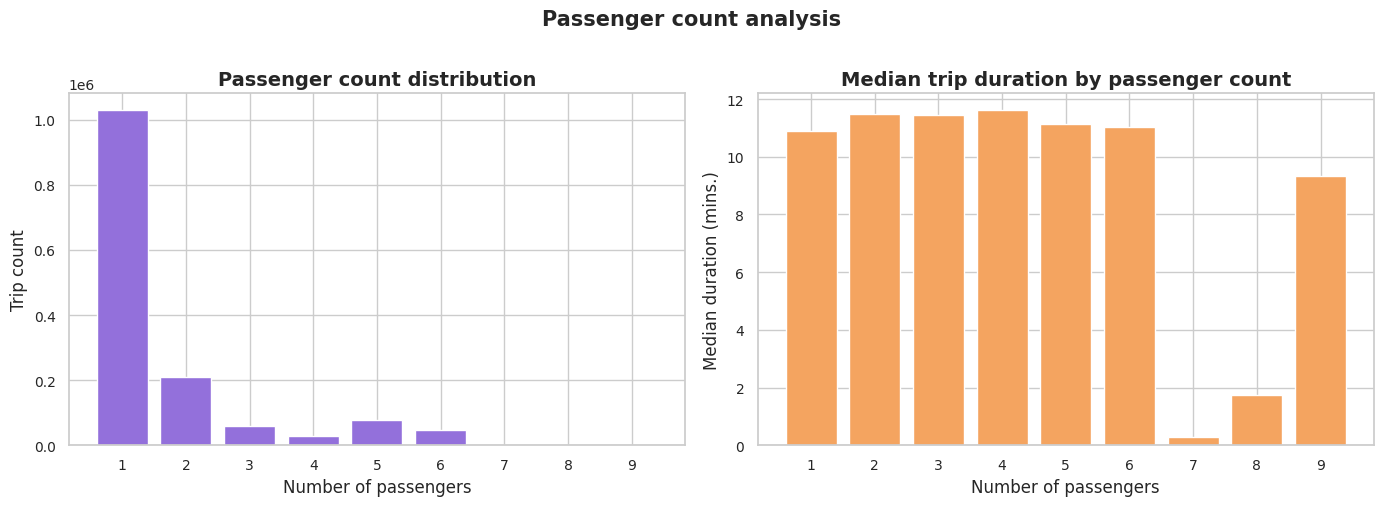

In [24]:
# Passenger count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count distribution
pax_counts = df['passenger_count'].value_counts().sort_index()
axes[0].bar(pax_counts.index, pax_counts.values,
            color='mediumpurple', edgecolor='white')
axes[0].set_title("Passenger count distribution")
axes[0].set_xlabel("Number of passengers")
axes[0].set_ylabel("Trip count")
axes[0].set_xticks(pax_counts.index)

# Duration by passenger count
pax_dur = df.groupby('passenger_count')['trip_duration'].median() / 60
axes[1].bar(pax_dur.index, pax_dur.values, color='sandybrown', edgecolor='white')
axes[1].set_title("Median trip duration by passenger count")
axes[1].set_xlabel("Number of passengers")
axes[1].set_ylabel("Median duration (mins.)")
axes[1].set_xticks(pax_dur.index)

plt.suptitle("Passenger count analysis", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

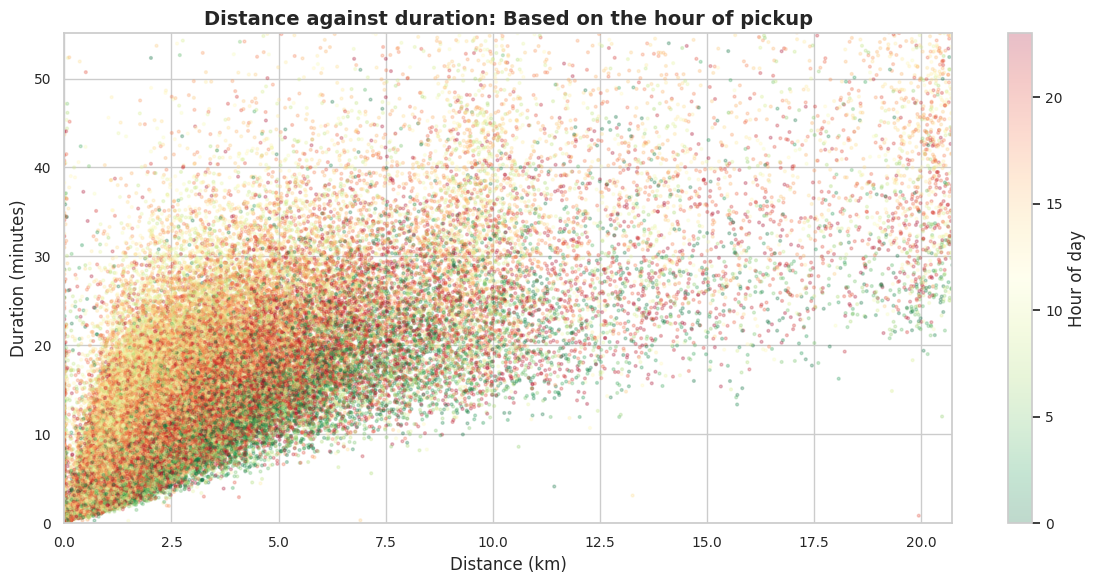

In [25]:
# Distance against duration scatter
sample = df.sample(n=min(100_000, len(df)), random_state=42)

cap_dist = df['distance_km'].quantile(0.99)
cap_dur  = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    sample['distance_km'], sample['trip_duration'] / 60,
    c=sample['hour'], cmap='RdYlGn_r', alpha=0.25, s=4,
    vmin=0, vmax=23
)
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.set_xlim(0, cap_dist)
ax.set_ylim(0, cap_dur / 60)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Duration (minutes)")
ax.set_title("Distance against duration: Based on the hour of pickup")
plt.tight_layout()
plt.show()

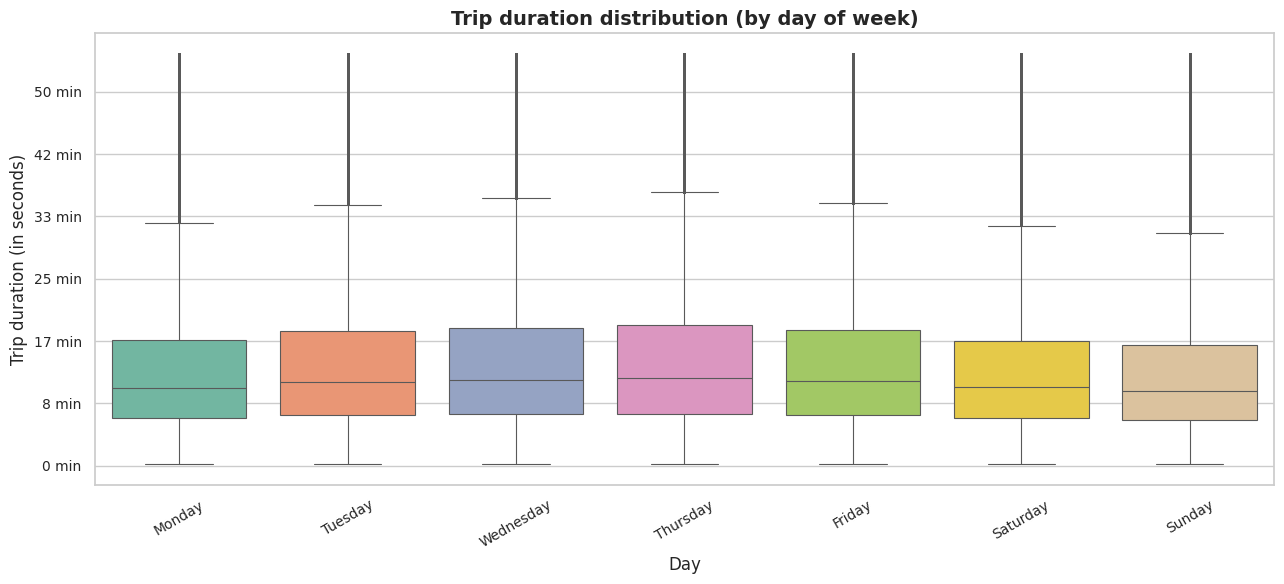

In [26]:
# Box plot
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cap_dur = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df[df['trip_duration'] <= cap_dur],
    x='day_of_week_name', y='trip_duration',
    order=day_order,
    palette='Set2', linewidth=0.8, fliersize=1,
    ax=ax
)
ax.set_title("Trip duration distribution (by day of week)")
ax.set_xlabel("Day")
ax.set_ylabel("Trip duration (in seconds)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/60:.0f} min"))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Correlation analysis

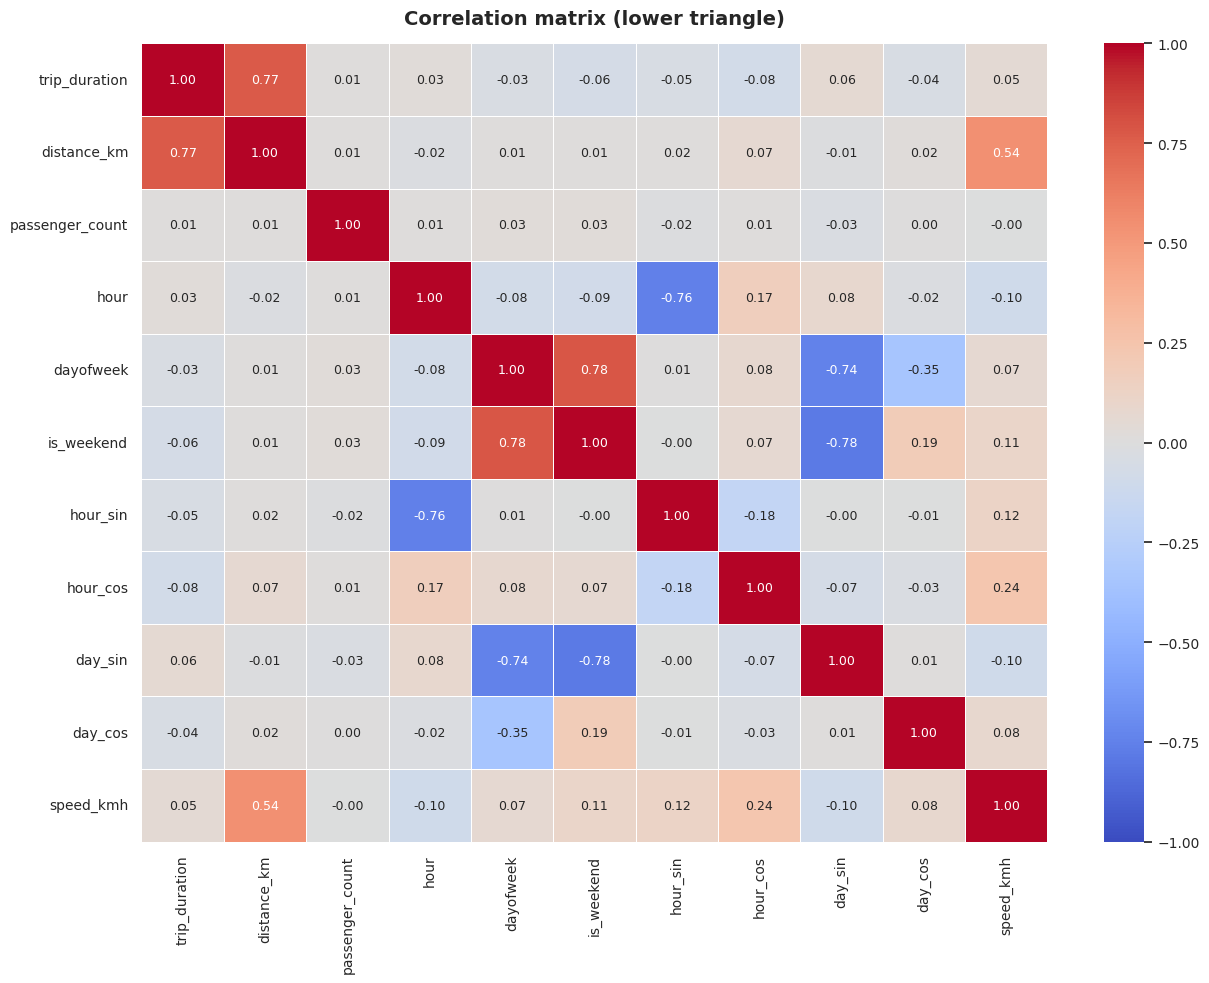

In [27]:
# Columns to include
corr_cols = [
    'trip_duration', 'distance_km', 'passenger_count',
    'hour', 'dayofweek', 'is_weekend',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'speed_kmh',   # Data-leaky, included for demonstration only
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)

ax.set_title("Correlation matrix (lower triangle)", pad=14)
plt.tight_layout()
plt.show()

# Modeling pipeline

In [28]:
import joblib
import sklearn
import xgboost

from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

In [29]:
# Feature lists
numeric_features = ["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude",
                    "passenger_count", "distance_km", "bearing", 
                    "hour_sin", "hour_cos", "day_sin","day_cos",]

categorical_features = ["vendor_id", "store_and_fwd_flag", "dayofweek", "month"]

# Column subset used as model input
model_columns = numeric_features + categorical_features + ["pickup_datetime"]

In [38]:
# Reusable feature engineering function (same as above but standalone)
def feature_engineering_pipeline(X: pd.DataFrame) -> pd.DataFrame:
    """
    Transforms raw input DataFrame into model-ready features.
    This function is wrapped in a FunctionTransformer so it becomes
    a proper sklearn pipeline step.
    """
    X = X.copy()
    X["pickup_datetime"] = pd.to_datetime(X["pickup_datetime"])
    dt = X["pickup_datetime"].dt

    # Spatial
    X["distance_km"] = calculate_distance(
        X["pickup_longitude"], X["pickup_latitude"],
        X["dropoff_longitude"], X["dropoff_latitude"]
    )
    X["bearing"] = calculate_bearing(
        X["pickup_longitude"], X["pickup_latitude"],
        X["dropoff_longitude"], X["dropoff_latitude"]
    )

    # Temporal
    X["hour"]      = dt.hour
    X["dayofweek"] = dt.dayofweek
    X["month"]     = dt.month

    # Cyclical
    X["hour_sin"] = np.sin(2 * np.pi * X["hour"]      / 24)
    X["hour_cos"] = np.cos(2 * np.pi * X["hour"]      / 24)
    X["day_sin"]  = np.sin(2 * np.pi * X["dayofweek"] /  7)
    X["day_cos"]  = np.cos(2 * np.pi * X["dayofweek"] /  7)

    # Drop datetime — not needed downstream
    X.drop(columns=["pickup_datetime"], inplace=True)

    return X

def build_pipeline() -> Pipeline:
    """
    Assembles the full sklearn pipeline:
      1. Feature engineering  (FunctionTransformer)
      2. Column preprocessing (ColumnTransformer: OHE + StandardScaler)
      3. XGBoost regressor
    """
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
             categorical_features),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )

    model = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        max_depth=10,
        subsample=0.9,
        colsample_bytree=0.7,
        min_child_weight=5,
        gamma=0.1,
        n_jobs=-1,
        tree_method='hist',
        random_state=42,
        objective='reg:squarederror',
        eval_metric='rmse'
    )

    return Pipeline([
        ("features",   FunctionTransformer(feature_engineering_pipeline)),
        ("processor",  preprocessor),
        ("model",      model),
    ])

# Train, validation split and training

In [39]:
# Load the raw data again (pipeline starts from raw inputs)
raw = pd.read_csv('/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip')

# Apply the same domain-knowledge cleaning as above
raw = clean_data(raw)

# Keep only columns the pipeline actually needs
input_cols = [
    "pickup_datetime", "vendor_id", "store_and_fwd_flag",
    "pickup_latitude", "pickup_longitude",
    "dropoff_latitude", "dropoff_longitude",
    "passenger_count"
]

train_df, val_df = train_test_split(raw, test_size=0.2, random_state=42)

X_train = train_df[input_cols].copy()
y_train = np.log1p(train_df["trip_duration"])   # log-transform target

X_val   = val_df[input_cols].copy()
y_val   = val_df["trip_duration"]               # raw seconds for final eval

print(f"Training: {len(X_train):,} samples")
print(f"Validation: {len(X_val):,} samples")

Training: 1,162,817 samples
Validation: 290,705 samples


In [40]:
# Build and train the model
pipeline = build_pipeline()

# Pre-transform validation set (pass it as eval_set for early stopping)
fe_step  = pipeline.named_steps['features']
pre_step = pipeline.named_steps['processor']

X_train_fe = fe_step.transform(X_train)
X_val_fe   = fe_step.transform(X_val)

# Fit preprocessor on training data, transform both splits
pre_step.fit(X_train_fe)
X_train_proc = pre_step.transform(X_train_fe)
X_val_proc   = pre_step.transform(X_val_fe)

# Train the model with early stopping
pipeline.named_steps['model'].fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, np.log1p(y_val))],
    verbose=200,
)

print("n\DONE TRANING")

[0]	validation_0-rmse:0.73837
[200]	validation_0-rmse:0.33834
[400]	validation_0-rmse:0.33055
[600]	validation_0-rmse:0.32733
[800]	validation_0-rmse:0.32582
[1000]	validation_0-rmse:0.32531
[1200]	validation_0-rmse:0.32498
[1400]	validation_0-rmse:0.32464
[1600]	validation_0-rmse:0.32446
[1800]	validation_0-rmse:0.32430
[1999]	validation_0-rmse:0.32415
n\DONE TRANING


# Evaluation

In [41]:
from sklearn.metrics import mean_squared_log_error

In [42]:
# Predict on validation set using the full pipeline
y_pred_log = pipeline.predict(X_val)           # log-space predictions
y_pred     = np.expm1(y_pred_log)              # back to raw seconds

r2   = r2_score(y_val, y_pred)
rmse = root_mean_squared_error(y_val, y_pred)
rmsle = np.sqrt(mean_squared_log_error(
    np.maximum(y_val, 0), np.maximum(y_pred, 0)
))

print("=" * 40)
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.1f} seconds  ({rmse/60:.1f} minutes)")
print(f"RMSLE: {rmsle:.4f}")
print("=" * 40)

R²: 0.8125
RMSE: 283.6 seconds  (4.7 minutes)
RMSLE: 0.3242


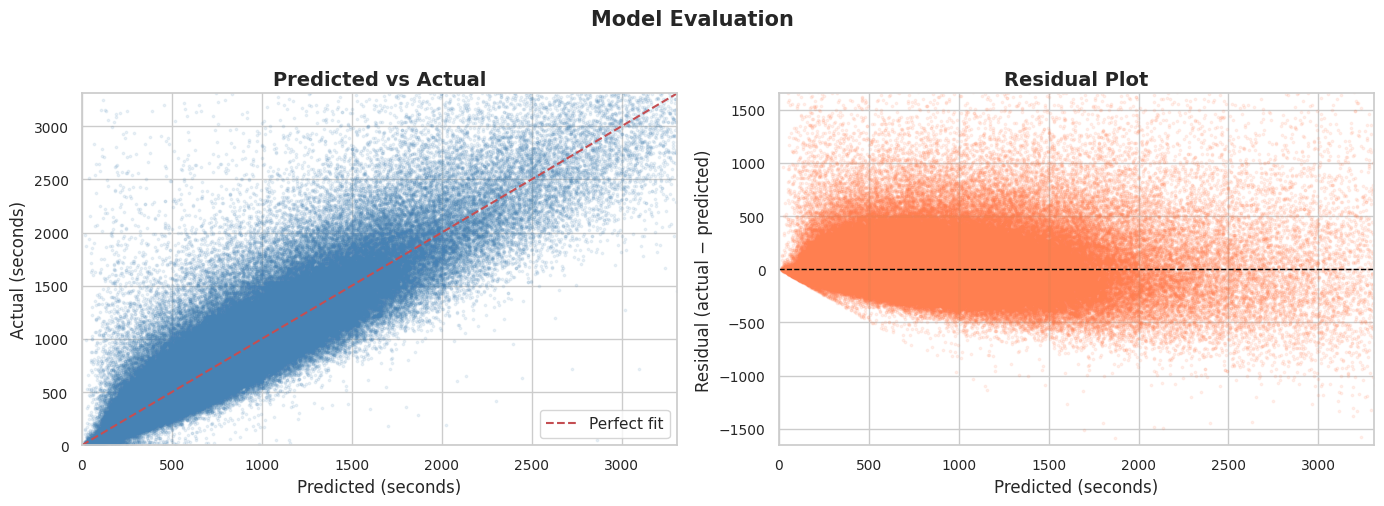

In [43]:
# Import MSLE function library
from sklearn.metrics import mean_squared_log_error

# Residual plot
residuals = y_val - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
cap = np.percentile(y_val, 99)
axes[0].scatter(y_pred, y_val, alpha=0.1, s=3, color='steelblue')
axes[0].plot([0, cap], [0, cap], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlim(0, cap); axes[0].set_ylim(0, cap)
axes[0].set_xlabel("Predicted (seconds)")
axes[0].set_ylabel("Actual (seconds)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# Residuals
axes[1].scatter(y_pred, residuals, alpha=0.1, s=3, color='coral')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlim(0, cap)
axes[1].set_ylim(-cap/2, cap/2)
axes[1].set_xlabel("Predicted (seconds)")
axes[1].set_ylabel("Residual (actual − predicted)")
axes[1].set_title("Residual Plot")

plt.suptitle("Model Evaluation", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

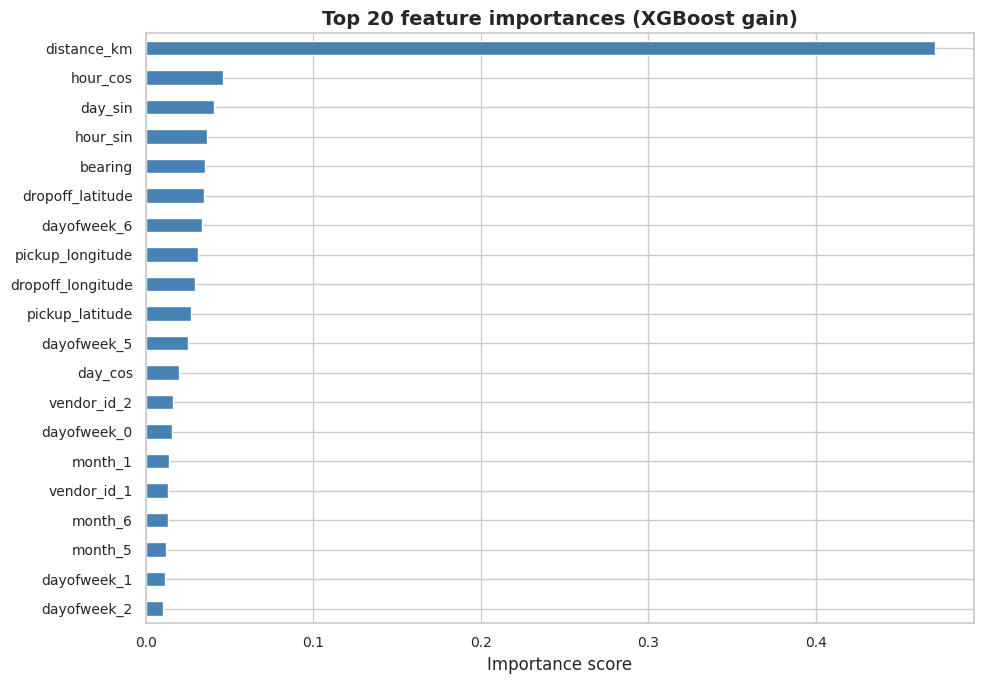

In [44]:
# Feature importance
booster    = pipeline.named_steps['model']
ohe        = pipeline.named_steps['processor'].named_transformers_['cat']
ohe_names  = ohe.get_feature_names_out(categorical_features).tolist()
feat_names = ohe_names + numeric_features

importance = pd.Series(
    booster.feature_importances_, index=feat_names
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Top 20 feature importances (XGBoost gain)")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

In [45]:
# Save as a new model
joblib.dump(pipeline, "nyc_taxi_xgb_ppln.pkl")
print("Pipeline successfully saved to a new .pkl format file.")

Pipeline successfully saved to a new .pkl format file.


In [48]:
test_raw = pd.read_csv("/kaggle/input/competitions/nyc-taxi-trip-duration/test.zip")
print(f"Shape: {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns")

test_ids = test_raw["id"]

X_test = test_raw[input_cols].copy()

print("\n Generating predictions...")

test_pred_log=pipeline.predict(X_test)
test_pred=np.expm1(test_pred_log)

Shape: 625,134 rows × 9 columns

 Generating predictions...


In [49]:
submission = pd.DataFrame({
    "id":            test_ids,
    "trip_duration": test_pred.astype(int),   # Kaggle expects integer seconds
})

output_path = "submission.csv"
submission.to_csv(output_path, index=False)

joblib.dump(pipeline, "nyc_taxi_xgb_pipeline.pkl")

print("Successfully saved as CSV file.")

Successfully saved as CSV file.
